# Kaggle F1 Data Visualization

In [27]:
import pandas as pd 
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plit

data_path = './data/kaggle_data/'

data_path = './data/kaggle_data/'
train = pd.read_csv(data_path + 'train.csv')
test = pd.read_csv(data_path + 'test.csv')
submission = pd.read_csv(data_path + 'sample_submission.csv')

In [28]:
train.head()


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [29]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

## 피처 요약

In [30]:
def resumetable(df, ordinal_threshold=20):
    """
    데이터프레임 각 컬럼의 변수 유형을 분류하여 요약 테이블을 반환합니다.
    - 이진형: 고유값이 정확히 2개
    - 명목형: 문자열/범주형 (고유값 > 2)
    - 순서형: 정수형이며 고유값이 ordinal_threshold 이하
    - 연속형: 실수형이거나 정수형이지만 고유값이 많은 경우
    """
    summary = []

    for col in df.columns:
        series = df[col]
        non_null = series.dropna()
        n_unique = non_null.nunique()
        dtype = series.dtype
        missing = series.isnull().sum()
        missing_pct = round(missing / len(series) * 100, 2)
        sample_vals = list(non_null.unique()[:5])

        # 변수 유형 판별
        if n_unique == 2:
            var_type = '이진형'
        elif dtype == object or str(dtype) == 'category':
            var_type = '명목형'
        elif str(dtype).startswith('int') or (str(dtype).startswith('float') and non_null.apply(float.is_integer).all()):
            var_type = '순서형' if n_unique <= ordinal_threshold else '연속형'
        else:
            var_type = '연속형'

        summary.append({
            'Column': col,
            'DType': str(dtype),
            'N_Unique': n_unique,
            'Missing': missing,
            'Missing(%)': missing_pct,
            'Variable Type': var_type,
            'Sample Values': sample_vals,
        })

    result = pd.DataFrame(summary).set_index('Column')
    return result




In [31]:
summary = resumetable(train)
summary

,DType,N_Unique,Missing,Missing(%),Variable Type,Sample Values
Column,,,,,,
id,int64,439140,0,0.0,연속형,"[0, 1, 2, 3, 4]"
Driver,object,887,0,0.0,명목형,"[D109, D086, ZON, SPE, D019]"
Compound,object,5,0,0.0,명목형,"[HARD, MEDIUM, INTERMEDIATE, SOFT, WET]"
Race,object,26,0,0.0,명목형,"[Canadian Grand Prix, Dutch Grand Prix, Austri..."
Year,int64,4,0,0.0,순서형,"[2022, 2025, 2023, 2024]"
PitStop,int64,2,0,0.0,이진형,"[0, 1]"
LapNumber,int64,78,0,0.0,연속형,"[50, 27, 59, 2, 26]"
Stint,int64,8,0,0.0,순서형,"[2, 3, 1, 4, 5]"
TyreLife,float64,78,0,0.0,연속형,"[39.0, 7.0, 22.0, 2.0, 6.0]"


## 타깃값 분포 확인

In [32]:
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [33]:
# ax = mpl의 Axes 객체
def write_percent(ax, total_size):
    '''도형 객체를 순회하며 막대 그래프 상단에 타깃값 비율 표시'''
    for patch in ax.patches:
        height = patch.get_height()
        width = patch.get_width()
        left_coord = patch.get_x()
        percent = height/total_size * 100

        ax.text(left_coord + width/2.0,
                height + total_size * 0.001,
                '{:1.1f}%'.format(percent),
                ha='center')
        


Text(0.5, 1.0, 'Target Distribution')

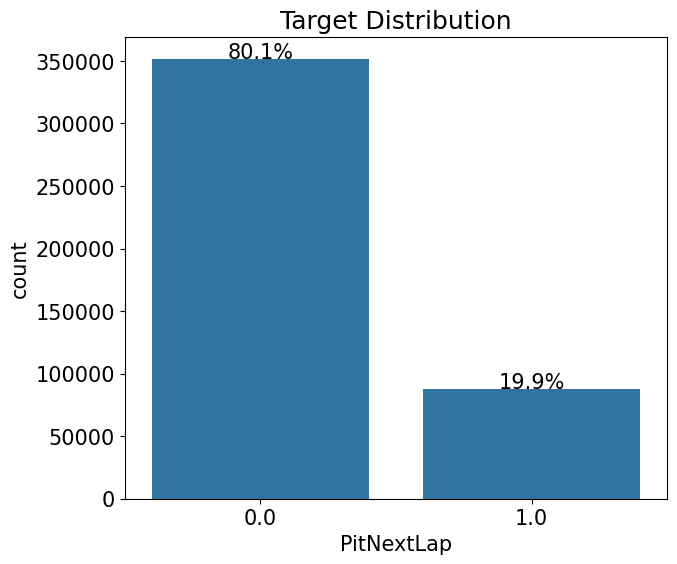

In [34]:
mpl.rc('font', size=15)
plt.figure(figsize=(7,6))

ax=sns.countplot(x='PitNextLap', data=train)
write_percent(ax, len(train))
ax.set_title('Target Distribution')

## 고윳값별 타깃값 예측력

## 이진 피처 예측력 확인

In [35]:
import matplotlib.gridspec as gridspec

def plot_target_ratio_by_features(df, features, num_rows, num_cols,
                                 size=(12, 18)):
    mpl.rc('font', size=9)
    plt.figure(figsize=size)
    grid = gridspec.GridSpec(num_rows, num_cols)
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    for idx, feature in enumerate(features):
        ax = plt.subplot(grid[idx])
        sns.barplot(x=feature, y='PitNextLap', data=df, palette='Set2', ax = ax)


/var/folders/f5/pg_hsgz552jdm_qgjnytp6340000gn/T/ipykernel_11230/1195427547.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='PitNextLap', data=df, palette='Set2', ax = ax)
/var/folders/f5/pg_hsgz552jdm_qgjnytp6340000gn/T/ipykernel_11230/1195427547.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='PitNextLap', data=df, palette='Set2', ax = ax)


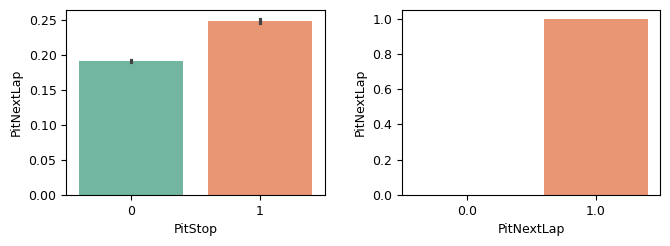

In [36]:
bin_features = summary[summary['Variable Type'] =='이진형'].index
plot_target_ratio_by_features(train, bin_features, 6, 3)

## 명목형 피처

/var/folders/f5/pg_hsgz552jdm_qgjnytp6340000gn/T/ipykernel_11230/1195427547.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='PitNextLap', data=df, palette='Set2', ax = ax)
/var/folders/f5/pg_hsgz552jdm_qgjnytp6340000gn/T/ipykernel_11230/1195427547.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='PitNextLap', data=df, palette='Set2', ax = ax)
/var/folders/f5/pg_hsgz552jdm_qgjnytp6340000gn/T/ipykernel_11230/1195427547.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='PitNextLap', data=df, pa

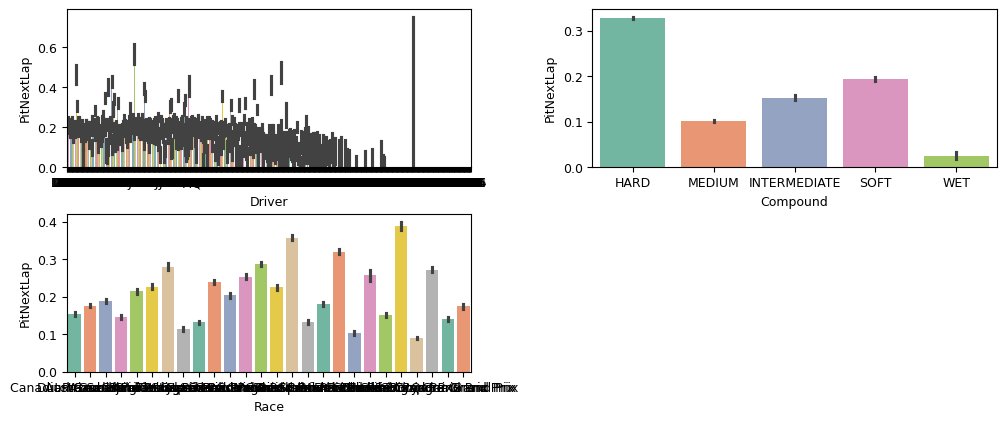

In [37]:
nom_features = summary[summary['Variable Type'] == '명목형'].index
plot_target_ratio_by_features(train, nom_features, 7, 2)

## 순서형 피처

/var/folders/f5/pg_hsgz552jdm_qgjnytp6340000gn/T/ipykernel_11230/1195427547.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='PitNextLap', data=df, palette='Set2', ax = ax)
/var/folders/f5/pg_hsgz552jdm_qgjnytp6340000gn/T/ipykernel_11230/1195427547.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='PitNextLap', data=df, palette='Set2', ax = ax)
/var/folders/f5/pg_hsgz552jdm_qgjnytp6340000gn/T/ipykernel_11230/1195427547.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature, y='PitNextLap', data=df, pa

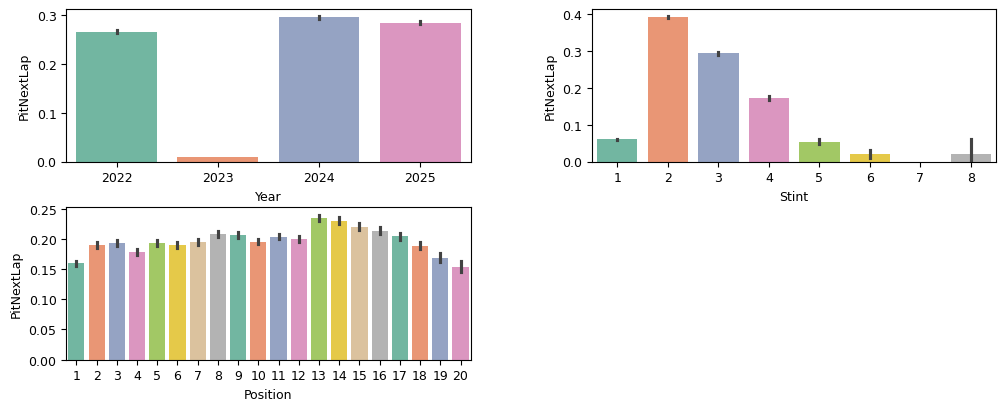

In [38]:
ord_features = summary[summary['Variable Type'] == '순서형'].index
plot_target_ratio_by_features(train, ord_features, 8, 2, (12,20))

## 연속형 피처

In [39]:
pd.cut([1.0, 1.5, 2.1, 2.7, 3.5, 4.0], 3)

[(0.997, 2.0], (0.997, 2.0], (2.0, 3.0], (2.0, 3.0], (3.0, 4.0], (3.0, 4.0]]
Categories (3, interval[float64, right]): [(0.997, 2.0] < (2.0, 3.0] < (3.0, 4.0]]

/var/folders/f5/pg_hsgz552jdm_qgjnytp6340000gn/T/ipykernel_11230/1299012074.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cont_feature, y='PitNextLap', data=train, palette='Set2', ax=ax)
/var/folders/f5/pg_hsgz552jdm_qgjnytp6340000gn/T/ipykernel_11230/1299012074.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cont_feature, y='PitNextLap', data=train, palette='Set2', ax=ax)
/var/folders/f5/pg_hsgz552jdm_qgjnytp6340000gn/T/ipykernel_11230/1299012074.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cont_feature, y='PitNext

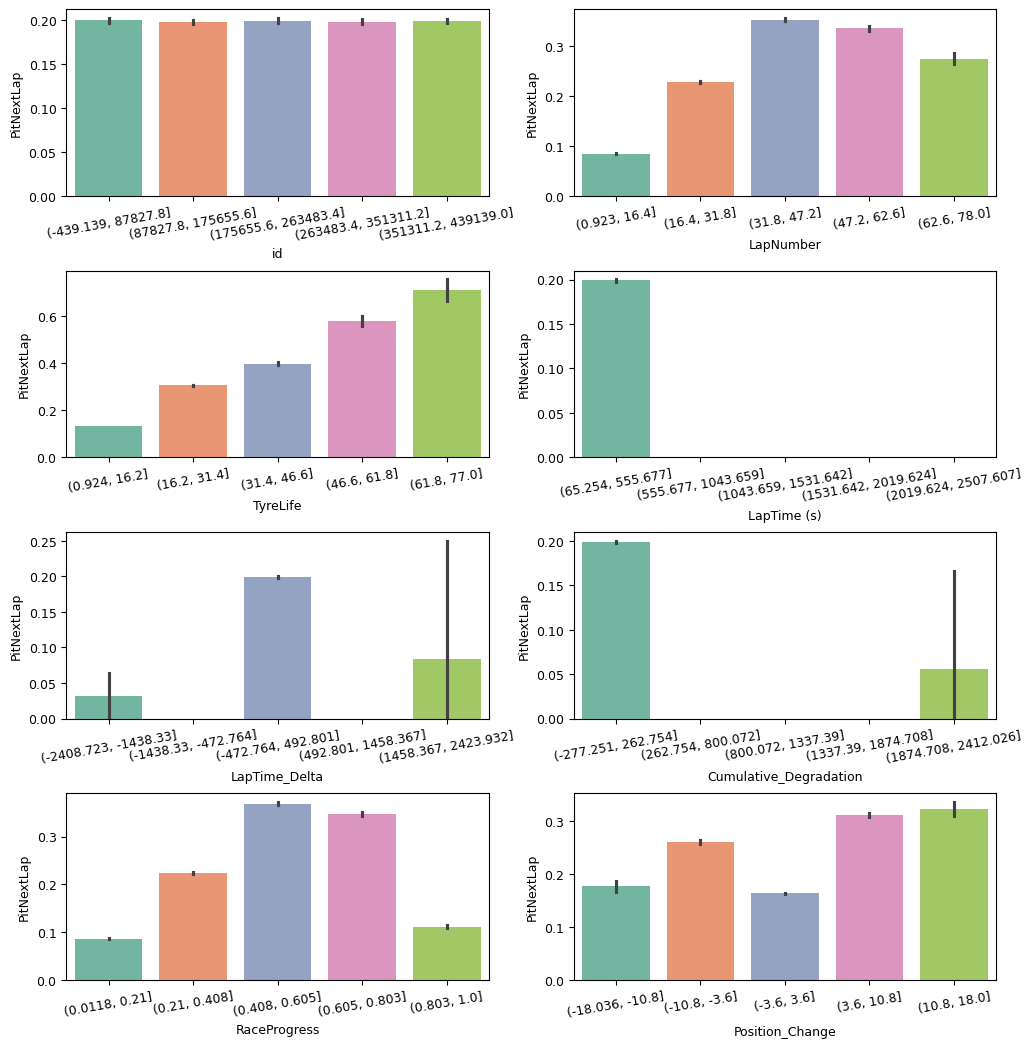

In [40]:
cont_features = summary[summary['Variable Type'] =='연속형'].index

plt.figure(figsize=(12, 16))
grid = gridspec.GridSpec(5,2)
plt.subplots_adjust(wspace=0.2, hspace=0.4)

for idx, cont_feature in enumerate(cont_features):
    train[cont_feature] = pd.cut(train[cont_feature], 5)

    ax = plt.subplot(grid[idx])
    sns.barplot(x=cont_feature, y='PitNextLap', data=train, palette='Set2', ax=ax)
    ax.tick_params(axis='x', labelrotation=10)

In [ ]:
plt.figure(figxize)